# Лабораторная работа 1

Тема: **Искусственный нейрон и функции активации**  
Цель: познакомиться с моделью искусственного нейрона, реализовать основные функции активации и визуализировать решающую границу на плоскости.

> ВАЖНО: все формулировки заданий в этом ноутбуке достаточно общие и абстрактные.  
> Не копируйте их целиком в сторонние сервисы автоматической генерации решений.  
> Оценка будет ставиться только за ваш собственный код, графики и пояснения.

## 1. Вводные теоретические вопросы

Ответьте **своими словами** на вопросы ниже. Строго запрещается вставлять сюда автоматически сгенерированный текст; преподаватель проверяет стиль и логику изложения.

1. Что такое искусственный нейрон? Какие величины входят в его модель и что они означают?
2. Зачем в нейронной сети нужна функция активации? Что будет, если использовать только линейные функции?
3. Назовите не менее трех различных функций активации и кратко опишите их поведение (какие значения принимают, где насыщаются, где линейны).
4. Как можно интерпретировать выход одного нейрона в задачах бинарной классификации?

Напишите ответы в следующей ячейке (в свободной форме, 5–10 предложений суммарно).

### Ответы на теоретические вопросы (заполните самостоятельно)

_Напишите здесь текст своими словами.  
Не копируйте формулировки из конспекта или интернета дословно — важно, чтобы вы сами понимали материал._

In [40]:
# Здесь должен быть ваш текстовый ответ, оформленный как многострочная строка, 
# комментарии или вывод через print.

theory_answer = """1)Это вычислительный элемент, который  преобразует несколько входных сигналов в один выходной сигнал. В состав искусственного нейрона входят:
- Входные сигналы - получаемые в нейрон данные
- Веса - параметр важности связи между узлами нейрона
- Функция активации - функция определения выходного сигнала по представленным входным данным
- Выходной сигнал - результат работы функции активации
2)Функция активации нужна, чтобы найти выходной сигнал по какому-то набору изначальных параметров, а также чтобы задать нелинейность сети. Если использовать только линейные функции, то в таком случае любая сеть становится однослойной, что в свою очередь неприменимо для сложных задач.
3)Типы функций активаций:
   - Сигмоида - преобразует вход в диапазон [0, 1]. Принимает на вход любое действительное число, насыщается при стремлении к -∞ или +∞, нелинейна на всем диапазоне.
   - Tanh - относительна похожа на сигмоиду, но выдает значения в [-1, 1]. Принимает на вход любое действительное число, насыщается при стремлении к -∞ или +∞, нелинейна на всем диапазоне.
   - ReLU - отрицательные значения превращает в 0, положительные оставляет без изменений. Принимает на вход числа от 0 до +∞, насыщается только на отрицательной части, на положительном участке линейна, на отрицательном участке константно-нулевая
4)В бинарной классификации выход одного нейрона можно интерпретировать как вероятность принадлежности к одному из классов. Выходной слой нейросети выдает вектор вероятностей для всех классов."""

print(theory_answer)

1)Это вычислительный элемент, который  преобразует несколько входных сигналов в один выходной сигнал. В состав искусственного нейрона входят:
- Входные сигналы - получаемые в нейрон данные
- Веса - параметр важности связи между узлами нейрона
- Функция активации - функция определения выходного сигнала по представленным входным данным
- Выходной сигнал - результат работы функции активации
2)Функция активации нужна, чтобы найти выходной сигнал по какому-то набору изначальных параметров, а также чтобы задать нелинейность сети. Если использовать только линейные функции, то в таком случае любая сеть становится однослойной, что в свою очередь неприменимо для сложных задач.
3)Типы функций активаций:
   - Сигмоида - преобразует вход в диапазон [0, 1]. Принимает на вход любое действительное число, насыщается при стремлении к -∞ или +∞, нелинейна на всем диапазоне.
   - Tanh - относительна похожа на сигмоиду, но выдает значения в [-1, 1]. Принимает на вход любое действительное число, насыщается 

## 2. Импорт библиотек и базовые настройки

Выполните импорт необходимых библиотек и задайте настройки визуализации.  
Используйте только те библиотеки, которые разрешены преподавателем.

**Задание 2.1.**
- Импортируйте `numpy` и `matplotlib.pyplot`.  
- Установите фиксированное зерно генератора случайных чисел для воспроизводимости.  
- Включите любой стиль оформления графиков (по вашему выбору).

In [4]:
import numpy as np
import matplotlib.pyplot as plt

# Задайте зерно (seed) случайного генератора
np.random.seed(0)

# Выберите стиль оформления графиков (можно изменить, если хотите)
plt.style.use("seaborn-v0_8")  # при необходимости замените на другой стиль

print("Библиотеки успешно импортированы. Seed установлен.")

Библиотеки успешно импортированы. Seed установлен.


## 3. Реализация функций активации

В этом разделе вы реализуете несколько функций активации и построите их графики.

**Задание 3.1.** Реализуйте следующие функции активации:
- Линейная функция  
- Сигмоида  
- Гиперболический тангенс  
- ReLU (Rectified Linear Unit)

Каждая функция должна корректно работать как с отдельным числом, так и с массивом NumPy.

**Задание 3.2.** Постройте на одном графике зависимости этих функций от аргумента `z` на отрезке от −5 до 5.  
Сделайте осмысленные подписи осей и легенду на русском языке.

_Подсказка: если вы не уверены в формулах, сначала запишите их в тетрадке или на листке и только потом реализуйте в коде._

In [ ]:
# Реализуйте функции активации ЗДЕСЬ.
# Не оставляйте заглушки вида pass и None — каждая функция должна возвращать корректный результат.

def activation_linear(z):
    """Линейная функция активации."""
    # TODO: замените return z на более осмысленную реализацию, если сочтете нужным
    return z

def activation_sigmoid(z):
    """Сигмоида."""
    return 1 / (1 + np.exp(-z))
    # TODO: реализуйте сигмоидную функцию

def activation_tanh(z):
    """Гиперболический тангенс."""
    return np.tanh(z)
    # TODO: реализуйте tanh через np.tanh

def activation_relu(z):
    """Функция ReLU."""
    return np.maximum(0,z)
    # TODO: реализуйте ReLU через np.maximum

# Простейшая самопроверка на одном числе
test_value = -1.5
print("Проверка на одном значении:")
print("linear:", activation_linear(test_value))
print("sigmoid:", activation_sigmoid(test_value))
print("tanh:", activation_tanh(test_value))
print("ReLU:", activation_relu(test_value))

# Простейшая самопроверка на массиве
test_array = np.array([1.0, 2.0])
print("Проверка на массиве:")
print("linear:", activation_linear(test_array))
print("sigmoid:", activation_sigmoid(test_array))
print("tanh:", activation_tanh(test_array))
print("ReLU:", activation_relu(test_array))

Проверка на одном значении:
linear: -1.5
sigmoid: 0.18242552380635635
tanh: -0.9051482536448665
ReLU: 0.0
Проверка на массиве:
linear: [1. 2.]
sigmoid: [0.73105858 0.88079708]
tanh: [0.76159416 0.96402758]
ReLU: [1. 2.]


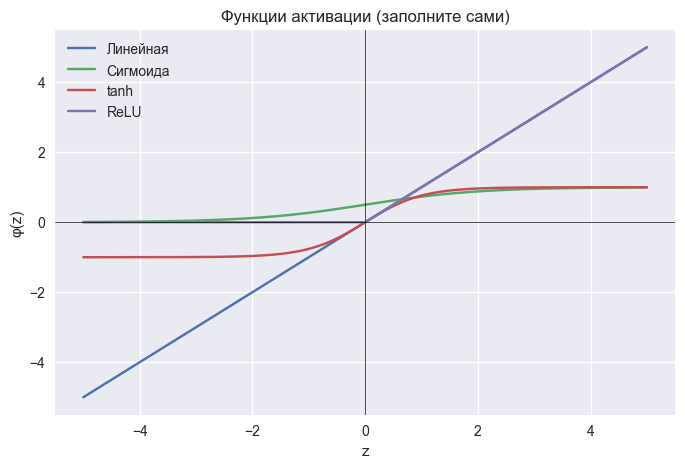

In [8]:
# ПОСТРОЙКА ГРАФИКОВ ФУНКЦИЙ АКТИВАЦИИ

z = np.linspace(-5, 5, 400)

plt.figure(figsize=(8, 5))
plt.plot(z, activation_linear(z), label="Линейная")
plt.plot(z, activation_sigmoid(z), label="Сигмоида")
plt.plot(z, activation_tanh(z), label="tanh")
plt.plot(z, activation_relu(z), label="ReLU")

plt.axhline(0, color="black", linewidth=0.5)
plt.axvline(0, color="black", linewidth=0.5)
plt.xlabel("z")
plt.ylabel("φ(z)")
plt.title("Функции активации (заполните сами)")
plt.legend()
plt.grid(True)
plt.show()

## 4. Реализация одиночного нейрона

Теперь реализуем модель одиночного нейрона, который:
- получает на вход вектор признаков `x`,
- умножает его на вектор весов `w`,
- добавляет смещение `b`,
- применяет одну из реализованных выше функций активации.

**Задание 4.1.** Реализуйте функцию `single_neuron(x, w, b, activation_name)`, которая:
- поддерживает вход `x` как одномерный массив (один объект) и как двумерный массив (несколько объектов),
- использует одну из функций активации по имени (`"linear"`, `"sigmoid"`, `"tanh"`, `"relu"`).

Не копируйте готовые куски кода из интернета: здесь важно, чтобы вы сами продумали форму массивов и математику.


In [ ]:
def single_neuron(x, w, b, activation_name="relu"):
    """Вычисляет выход одиночного нейрона для входа x.

    x: np.ndarray формы (n_features,) или (n_samples, n_features)
    w: np.ndarray формы (n_features,)
    b: число (смещение)
    activation_name: строка с названием функции активации
    """
    # Приводим x к двумерному виду для удобства вычислений
    x = np.asarray(x)
    if x.ndim == 1:
        x = x.reshape(1, -1)

    # TODO: реализуйте линейную комбинацию для z используя @ (матричное умножение - семантика np.matmul)
    z = x@w+b

    if activation_name == "linear":
        return activation_linear(z)
    elif activation_name == "sigmoid":
        return activation_sigmoid(z)
    elif activation_name == "tanh":
        return activation_tanh(z)
    elif activation_name == "relu":
        return activation_relu(z)
    else:
        raise ValueError("Неизвестная функция активации: " + str(activation_name))

# Краткая проверка на одном примере
# TODO: задайте одномерные массивы для входа и весов, и число для смещения
x_example = np.array([1,2,3])
w_example = np.array([6,7,8])
b_example = 0.66

for name in ["linear", "sigmoid", "tanh", "relu"]:
    y_example = single_neuron(x_example, w_example, b_example, name)
    print(f"Активация {name}, выход: {y_example}")

Активация linear, выход: [44.66]
Активация sigmoid, выход: [1.]
Активация tanh, выход: [1.]
Активация relu, выход: [44.66]


## 5. Визуализация решающей границы нейрона

Рассматриваем двумерный вход `x = (x1, x2)`. Для нейрона вида
\( $y = \sigma(w_1 x_1 + w_2 x_2 + b)$ \)  
линия уровня, соответствующая `y ≈ 0.5`, задает **решающую границу**.

**Задание 5.1.**
- Выберите произвольные значения весов `w1`, `w2` и смещения `b` (не все нули).  
- Постройте на плоскости поле значений выхода нейрона (например, с сигмоидой).  
- Нарисуйте линию решающей границы (уровень ~0.5 для сигмоиды).

**Задание 5.2.**
- С помощью изменения `w` и `b` проанализируйте, как меняется положение и наклон границы.  
- Сформулируйте **2–3 предложения** с описанием наблюдений в отдельной текстовой ячейке.


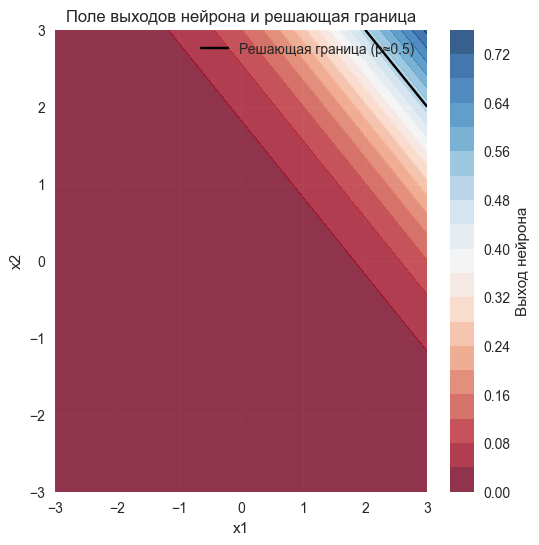

In [ ]:
# ВЫБОР ПАРАМЕТРОВ НЕЙРОНА (измени́те их и посмотрите на результат)
w_demo = np.array([1, 1])   # попробуйте разные значения
b_demo = 2                     # попробуйте сдвинуть границу

# Сетка точек на плоскости
x1_min, x1_max = -3.0, 3.0
x2_min, x2_max = -3.0, 3.0

xx1, xx2 = np.meshgrid(
    np.linspace(x1_min, x1_max, 200),
    np.linspace(x2_min, x2_max, 200)
)

grid = np.c_[xx1.ravel(), xx2.ravel()]

# Выход нейрона с сигмоидальной активацией
probs = single_neuron(grid, w_demo, b_demo, "sigmoid")
probs = probs.reshape(xx1.shape)

plt.figure(figsize=(6, 6))
cs = plt.contourf(xx1, xx2, probs, levels=20, cmap="RdBu", alpha=0.8)
plt.colorbar(cs, label="Выход нейрона")

# Линия решающей границы (уровень ~0.5)
contours = plt.contour(xx1, xx2, probs, levels=[0.5], colors="black")
plt.plot([], [], color="black", label="Решающая граница (p≈0.5)")

plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Поле выходов нейрона и решающая граница")
plt.legend()
plt.grid(True)
plt.show()

### Комментарии по влиянию параметров на решающую границу

_Опишите своими словами, как изменение вектора весов и смещения влияет на положение и наклон границы.  
Ответ должен опираться на ваши собственные эксперименты с кодом выше (изменение `w_demo` и `b_demo`)._

In [39]:
boundary_comment = """При увеличении вектора меняется угол наклона решающей границы, к примеру при увеличении параметра w1 угол наклона относительно оси x1 возрастает, при уменьшении соответственно уменьшается.
При изменении сдвига соответственно сдвигается сама решающая граница, при увеличении параметра b сдвиг наблюдается в отрицательную сторону относительно вектора {x1,x2}, в обратную сторону обратный эффект."""

print(boundary_comment)

При увеличении вектора меняется угол наклона решающей границы, к примеру при увеличении параметра w1 угол наклона относительно оси x1 возрастает, при уменьшении соответственно уменьшается.
При изменении сдвига соответственно сдвигается сама решающая граница, при увеличении параметра b сдвиг наблюдается в отрицательную сторону относительно вектора {x1,x2}, в обратную сторону обратный эффект.


## 6. Ручной подбор нейрона для разделения двух классов

Сгенерируем на плоскости два кластера точек (два класса) и попробуем подобрать параметры нейрона так, чтобы он их разделял.

**Задание 6.1.**
- Сгенерируйте два набора точек (по 50–200 в каждом) из разных двумерных нормальных распределений (центры и ковариации выберите сами).  
- Объедините их в одну выборку `X` и массив меток `y` (0 и 1).

**Задание 6.2.**
- Подберите вручную (методом проб и ошибок) веса `w_try` и смещение `b_try` для нейрона с сигмоидой.  
- Визуализируйте точки двух классов и решающую границу.  
- Оцените долю правильно классифицированных точек.

Рекомендуется **несколько раз менять** параметры и смотреть, как меняется качество разделения. Это важная часть работы и проверка интуиции.

In [42]:
# ГЕНЕРАЦИЯ ДВУХ КЛАССОВ

n_samples = 100  # при желании можно изменить

# TODO: Задайте центры и ковариационные матрицы для двух классов
mean_class0 = np.array([1, 1])
mean_class1 = np.array([4, 4])

cov_class0 = np.array([[1, 0.3],
                       [0.3, 1]])
cov_class1 = np.array([[1.0, -0.2],
                       [-0.2, 1.0]])

class0 = np.random.multivariate_normal(mean_class0, cov_class0, size=n_samples)
class1 = np.random.multivariate_normal(mean_class1, cov_class1, size=n_samples)

# Объедините массивы class0 и class1 в одну матрицу X формы (n_samples, 2)
# Подсказка: используйте функции объединения из numpy (например, vstack или concatenate)
X = np.vstack([class0, class1])

# TODO: Создайте вектор ответов y формы (n_samples,).
# Первые n_samples элементов должны быть 0, а вторые n_samples элементов — 1.
y = np.array([0]*n_samples+[1]*n_samples)

print("Форма X:", X.shape)
print("Форма y:", y.shape)

Форма X: (200, 2)
Форма y: (200,)


Доля правильных классификаций при w=[1. 1.], b=-5: 0.960


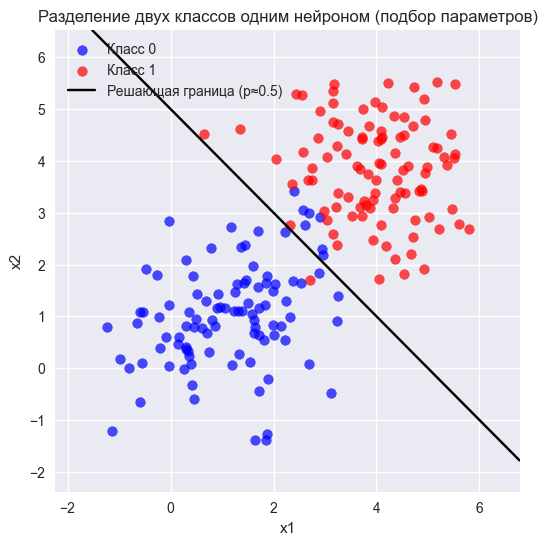

In [47]:
# РУЧНОЙ ПОДБОР ПАРАМЕТРОВ НЕЙРОНА

# Попробуйте изменить эти значения и перезапустить ячейку
w_try = np.array([1.0, 1.0])
b_try = -5

# Выход нейрона (вероятности для класса 1)
probs_data = single_neuron(X, w_try, b_try, activation_name="sigmoid").ravel()
# TODO: Переведите вероятности (probs_data) в бинарные предсказания классов (0 или 1).
# Подсказка: используйте порог 0.5. Все, что больше или равно — класс 1, иначе — 0. Не забудьте привести к int
y_pred = (probs_data >=0.5).astype(int)
# TODO: Посчитайте долю правильных ответов (accuracy).
# Сравните предсказанные метки y_pred с истинными метками y.
accuracy = np.mean(y_pred == y)

print(f"Доля правильных классификаций при w={w_try}, b={b_try}: {accuracy:.3f}")

# Визуализация
plt.figure(figsize=(6, 6))
plt.scatter(class0[:, 0], class0[:, 1], c="blue", label="Класс 0", alpha=0.7)
plt.scatter(class1[:, 0], class1[:, 1], c="red", label="Класс 1", alpha=0.7)

# Решающее множество на сетке для визуализации границы
x1_min_data, x1_max_data = X[:, 0].min() - 1, X[:, 0].max() + 1
x2_min_data, x2_max_data = X[:, 1].min() - 1, X[:, 1].max() + 1

xx1_d, xx2_d = np.meshgrid(
    np.linspace(x1_min_data, x1_max_data, 200),
    np.linspace(x2_min_data, x2_max_data, 200)
)

grid_d = np.c_[xx1_d.ravel(), xx2_d.ravel()]
probs_grid_d = single_neuron(grid_d, w_try, b_try, activation_name="sigmoid").reshape(xx1_d.shape)

contours_d = plt.contour(xx1_d, xx2_d, probs_grid_d, levels=[0.5], colors="black")
plt.plot([], [], color="black", label="Решающая граница (p≈0.5)")

plt.xlabel("x1")
plt.ylabel("x2")
plt.title("Разделение двух классов одним нейроном (подбор параметров)")
plt.legend()
plt.grid(True)
plt.show()

### Краткие выводы по разделению классов

_Сформулируйте 3–5 предложений о том, удалось ли разделить классы одним нейроном,  
насколько хорошо это получилось и от чего зависит качество разделения._

In [50]:
separation_comment = """В ходе экспериментов с ручным подбором параметров нейрона удалось добиться хорошего разделения двух классов.
Используя w=[1.0, 1.0] и b=-5.0, граница проходит примерно посередине между кластерами, что даёт значение accuracy >0.9.
Качество разделения напрямую зависит от того, насколько хорошо линейная граница соответствует реальному расположению классов в пространстве признаков.
Поскольку оба класса генерировались из нормальных распределений с разными центрами (1,1) и (4,4), один нейрон справляется с задачей достаточно хорошо.
Однако при сильном перекрытии классов или нелинейной форме границы один нейрон окажется недостаточным — потребуется многослойная сеть."""

print(separation_comment)

В ходе экспериментов с ручным подбором параметров нейрона удалось добиться хорошего разделения двух классов.
Используя w=[1.0, 1.0] и b=-5.0, граница проходит примерно посередине между кластерами, что даёт значение accuracy >0.9.
Качество разделения напрямую зависит от того, насколько хорошо линейная граница соответствует реальному расположению классов в пространстве признаков.
Поскольку оба класса генерировались из нормальных распределений с разными центрами (1,1) и (4,4), один нейрон справляется с задачей достаточно хорошо.
Однако при сильном перекрытии классов или нелинейной форме границы один нейрон окажется недостаточным — потребуется многослойная сеть.


## 7. Итоговые выводы по лабораторной работе

В завершение сформулируйте **собственный** короткий вывод (5–8 предложений) по всей работе:
- какую модель вы реализовали,  
- что нового узнали про функции активации и решающие границы,  
- что показали эксперименты с двумя классами данных.

Этот раздел очень важен для оценки: по нему видно, что вы действительно продумали проделанные шаги.

In [49]:
final_conclusion = """В данной лабораторной работе была реализована модель искусственного нейрона с несколькими функциями активации: линейной, сигмоидой, гиперболическим тангенсом и ReLU.
Эксперименты с графиками показали принципиальное отличие нелинейных функций от линейной - сигмоида и tanh ограничивают выход определённым диапазоном и насыщаются при больших значениях входа, а ReLU обнуляет отрицательную часть и линейна на положительной.
Из экспериментов с решающей границей стало понятно, что вектор весов w определяет направление разделяющей границы, а смещение b сдвигает её параллельно самой себе, не меняя угла.
Ручной подбор параметров для разделения двух кластеров наглядно показал, что одиночный нейрон задаёт строго линейную границу, поэтому хорошо работает лишь в линейно разделимых задачах.
Для классов с перекрывающимися распределениями или нелинейной формой границы точность неизбежно снизится - в таких случаях необходимо использовать многослойные нейронные сети."""

print(final_conclusion)

В данной лабораторной работе была реализована модель искусственного нейрона с несколькими функциями активации: линейной, сигмоидой, гиперболическим тангенсом и ReLU.
Эксперименты с графиками показали принципиальное отличие нелинейных функций от линейной - сигмоида и tanh ограничивают выход определённым диапазоном и насыщаются при больших значениях входа, а ReLU обнуляет отрицательную часть и линейна на положительной.
Из экспериментов с решающей границей стало понятно, что вектор весов w определяет направление разделяющей границы, а смещение b сдвигает её параллельно самой себе, не меняя угла.
Ручной подбор параметров для разделения двух кластеров наглядно показал, что одиночный нейрон задаёт строго линейную границу, поэтому хорошо работает лишь в линейно разделимых задачах.
Для классов с перекрывающимися распределениями или нелинейной формой границы точность неизбежно снизится - в таких случаях необходимо использовать многослойные нейронные сети.
